In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import importlib
import superlets_package.morlet as morlet
import superlets_package.superlets as superlet
from SingularSuperletPY import sst
from SingularSuperletPY import cwt

In [2]:
importlib.reload(morlet)
importlib.reload(superlet)
importlib.reload(sst)
importlib.reload(cwt)

<module 'SingularSuperletPY.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY/SingularSuperletPY/cwt.py'>

In [3]:
# test_signal = np.load('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_2.npy')
# plt.plot(test_signal)

In [4]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

In [5]:
fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * fs)

In [6]:
np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))

In [7]:
burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

In [8]:
start_idx = np.searchsorted(t, burst_start)  # Encuentra el índice de inicio
end_idx = np.searchsorted(t, burst_start + burst_duration)  # Encuentra el índice final

MNF ideal = 92.67754020405637
MNF analytic = 96.69316491703574


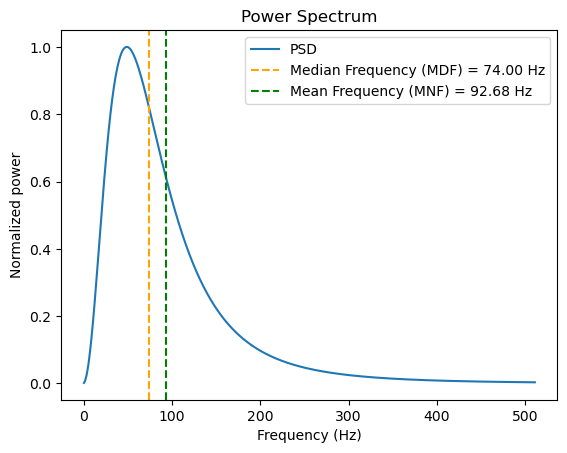

In [9]:
burst = []
[filtro, PdeLuca, burst, MNF_ideal, MNF_analytic] = superlet.fdeluca(100, 40, fs, burst_duration, plot = False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')
MNF_1 = [MNF_ideal]

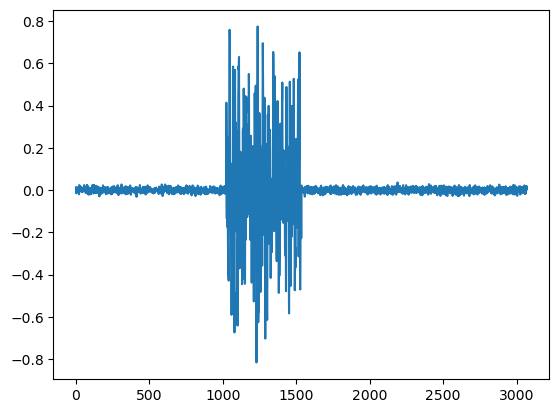

In [10]:
burst_signal = noise.copy()
burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
plt.plot(burst_signal)

In [11]:
test_signal = burst_signal

In [12]:
freqs = np.linspace(10,500,int(fs/2))

In [13]:
nfft = 2 * (len(freqs))
ms_per_cycle = 12.67

# Definir el espacio de los parámetros

In [14]:
def get_onset_offset(matrix, burst_start, burst_duration, t, Fs, smooth_sigma, plot=False, std_threshold=None):
    first_indices = []
    last_indices = []

    for row in matrix:
        first_idx, last_idx = superlet.find_plateau_region(
            row, burst_start, burst_duration, t, Fs,
            smooth_sigma=smooth_sigma, plot=plot, std_threshold=std_threshold
        )
        first_indices.append(first_idx)
        last_indices.append(last_idx)

    return t[first_indices], t[last_indices]

### Singular superlet

In [15]:
w_f = 0.005
w_t = 0.995
eps = 1e-12

norm = 'freq-sqrt'
smooth_sigma = 20


        SINGULAR SUPERLET → Barrido 2D baseCycle × step

Checking base cycle = 3
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 8
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 13
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 18
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 23
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 28
Checking 

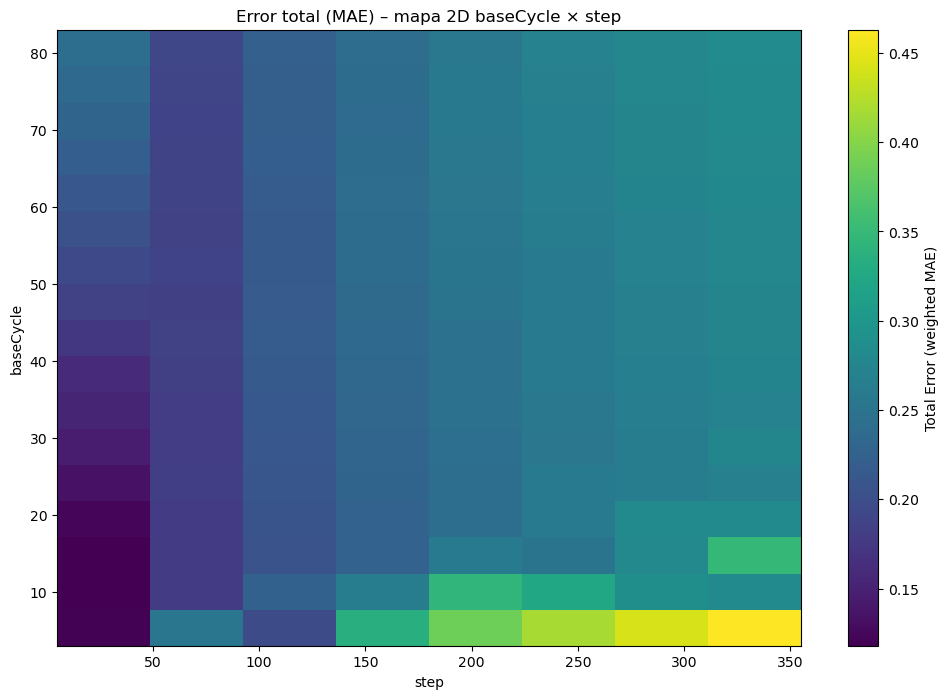


MÍNIMO 2D → interacción baseCycle × step
Mejor baseCycle = 8
Mejor step      = 5
Error mínimo    = 0.1180

     RANGO RECOMENDADO PARA OPTIMIZACIÓN BAYESIANA
BaseCycle óptimo: 8   (rango sugerido: 3 → 23)
Step óptimo:      5   (rango sugerido: 5 → 5)


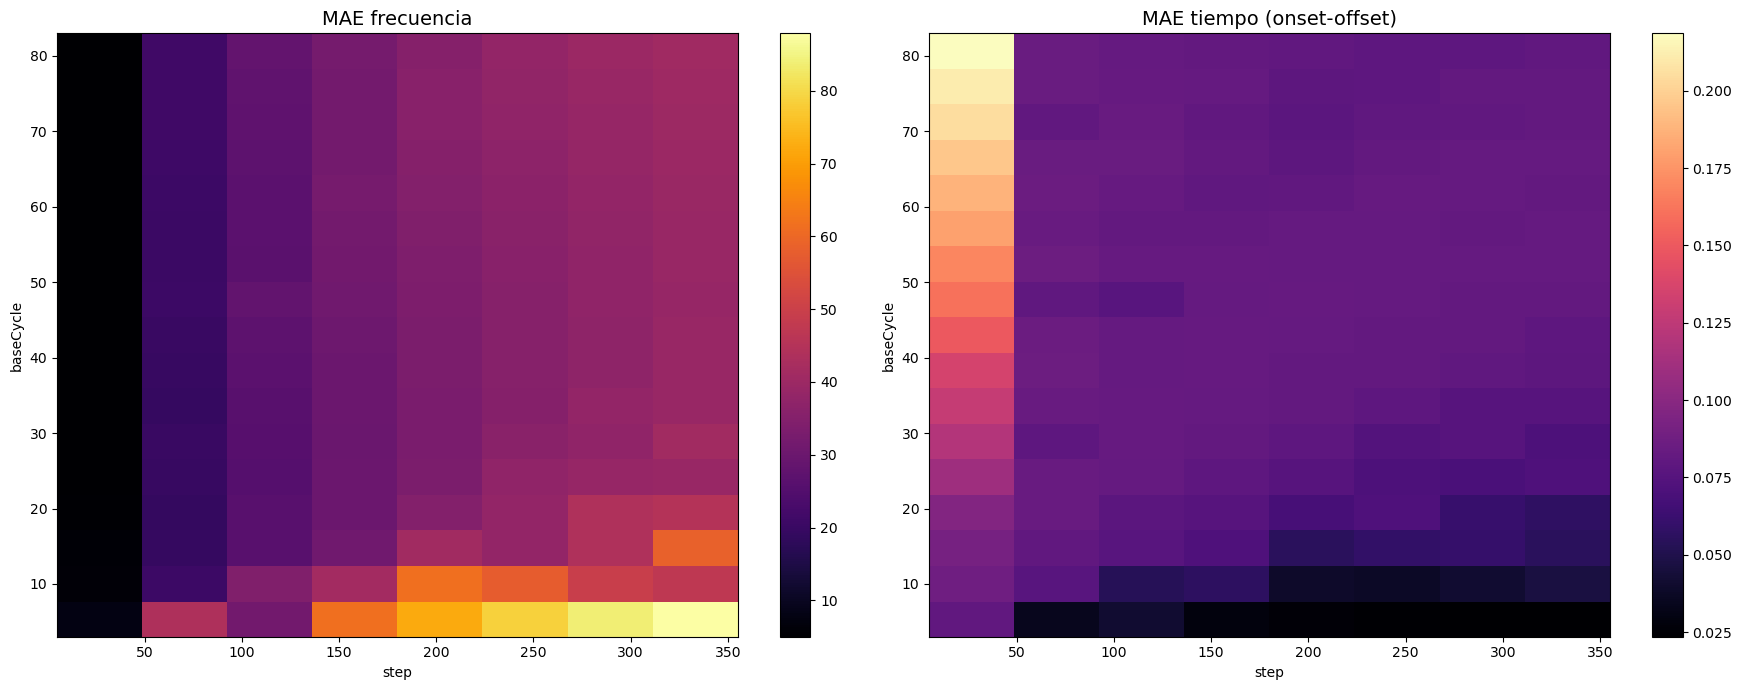

In [18]:
bases_2d = np.arange(3, 84, 5)
steps_2d = np.arange(5, 356, 50)

heatmap_total = np.zeros((len(bases_2d), len(steps_2d)))
heatmap_f = np.zeros_like(heatmap_total)
heatmap_t = np.zeros_like(heatmap_total)

print("\n==========================================================")
print("        SINGULAR SUPERLET → Barrido 2D baseCycle × step")
print("==========================================================\n")

for i, base in enumerate(bases_2d):
    print("==========================================================")
    print(f"Checking base cycle = {base}")
    for j, step in enumerate(steps_2d):
        print(f"Checking step = {step}")

        try:
            sstRez, o_min, o_max = sst.sst(test_signal, freqs, fs, base, norm, step)

            # ---- INSTANT FREQUENCY ----
            instant_freq = np.sum(sstRez * freqs[:, None], axis=0) / \
                           (np.sum(sstRez, axis=0) + eps)

            instant_freq_burst = instant_freq[start_idx:end_idx]
            mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

            # ---- ONSET / OFFSET ----
            t_on, t_off = get_onset_offset(
                sstRez,
                burst_start,
                burst_duration,
                t,
                fs,
                smooth_sigma,
                plot=False
            )
            mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

            total = w_f * mae_f + w_t * mae_t

        except Exception as e:
            print(f"ERROR base={base}, step={step}: {e}")
            mae_f = mae_t = total = np.nan

        heatmap_f[i, j] = mae_f
        heatmap_t[i, j] = mae_t
        heatmap_total[i, j] = total

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_total, origin="lower", cmap="viridis",
               extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
               aspect="auto")

plt.colorbar(im, ax=ax, label="Total Error (weighted MAE)")
ax.set_title("Error total (MAE) – mapa 2D baseCycle × step")
ax.set_xlabel("step")
ax.set_ylabel("baseCycle")

plt.show()


idx = np.nanargmin(heatmap_total)
best_i, best_j = np.unravel_index(idx, heatmap_total.shape)

best_base_2d = bases_2d[best_i]
best_step_2d = steps_2d[best_j]

print("\n==========================================================")
print("MÍNIMO 2D → interacción baseCycle × step")
print("==========================================================")
print(f"Mejor baseCycle = {best_base_2d}")
print(f"Mejor step      = {best_step_2d}")
print(f"Error mínimo    = {heatmap_total[best_i, best_j]:.4f}")

# Estimación de los rangos para la optimización

# --- definimos un umbral tipo "valle" ---
min_error = heatmap_total[best_i, best_j]
threshold = min_error * 1.20     # 20% por encima del mínimo → zona buena

valle = heatmap_total <= threshold

# --- obtener índices "buenos" para cada parámetro ---
bases_good  = bases_2d[np.where(valle.any(axis=1))]
steps_good  = steps_2d[np.where(valle.any(axis=0))]

# --- definir rango recomendado ---
recommended_base_min = bases_good.min()
recommended_base_max = bases_good.max()

recommended_step_min = steps_good.min()
recommended_step_max = steps_good.max()

print("\n==========================================================")
print("     RANGO RECOMENDADO PARA OPTIMIZACIÓN BAYESIANA")
print("==========================================================")
print(f"BaseCycle óptimo: {best_base_2d}   (rango sugerido: {recommended_base_min} → {recommended_base_max})")
print(f"Step óptimo:      {best_step_2d}   (rango sugerido: {recommended_step_min} → {recommended_step_max})")

# ===============================================================
#     HEATMAPS INDIVIDUALES → MAE FRECUENCIA y MAE TIEMPO
# ===============================================================

fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# -------------------- HEATMAP MAE FRECUENCIA --------------------
im1 = axs[0].imshow(
    heatmap_f,
    origin="lower",
    cmap="inferno",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[0].set_title("MAE frecuencia", fontsize=14)
axs[0].set_xlabel("step")
axs[0].set_ylabel("baseCycle")
plt.colorbar(im1, ax=axs[0])

# -------------------- HEATMAP MAE TIEMPO ------------------------
im2 = axs[1].imshow(
    heatmap_t,
    origin="lower",
    cmap="magma",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[1].set_title("MAE tiempo (onset-offset)", fontsize=14)
axs[1].set_xlabel("step")
axs[1].set_ylabel("baseCycle")
plt.colorbar(im2, ax=axs[1])

plt.tight_layout()
plt.show()


### Adaptive Continuous Wavelet Transform


        CWT → Barrido 2D baseCycle × step

Checking base cycle = 3
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 8
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 13
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 18
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 23
Checking step = 5
Checking step = 55
Checking step = 105
Checking step = 155
Checking step = 205
Checking step = 255
Checking step = 305
Checking step = 355
Checking base cycle = 28
Checking step = 5
Check

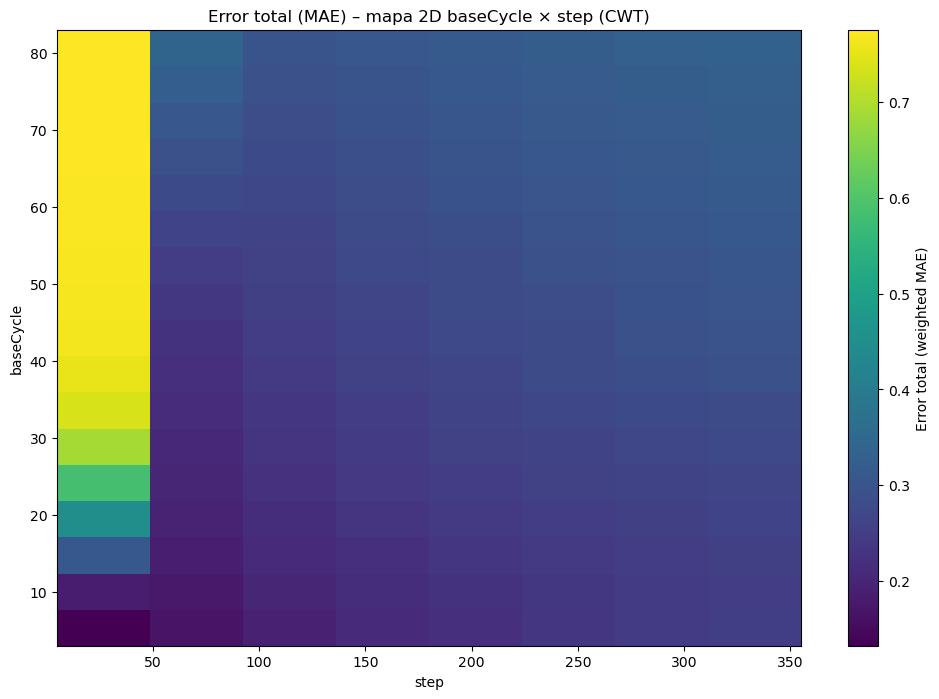


MÍNIMO 2D → interacción baseCycle × step (CWT)
Mejor baseCycle = 3
Mejor step      = 5
Error mínimo    = 0.1328

Rango sugerido para optimización bayesiana:
baseCycle: [3, 23]
step:      [5, 55]


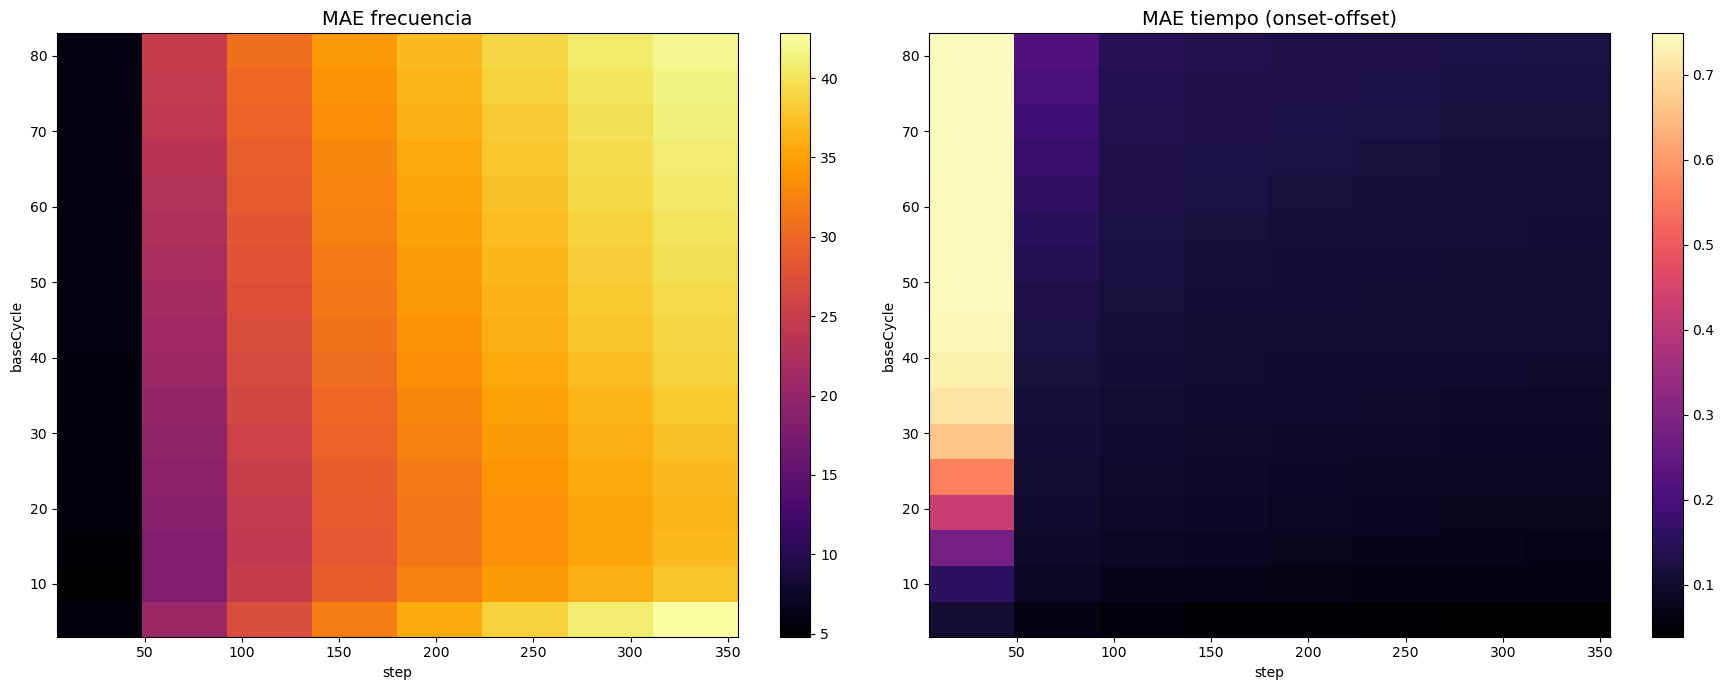

In [19]:
bases_2d = np.arange(3, 84, 5)  # rango ejemplo para baseCycle
steps_2d = np.arange(5, 356, 50)  # rango ejemplo para step

heatmap_total = np.zeros((len(bases_2d), len(steps_2d)))
heatmap_f = np.zeros_like(heatmap_total)
heatmap_t = np.zeros_like(heatmap_total)

print("\n==========================================================")
print("        CWT → Barrido 2D baseCycle × step")
print("==========================================================\n")

for i, base in enumerate(bases_2d):
    print("==========================================================")
    print(f"Checking base cycle = {base}")
    for j, step in enumerate(steps_2d):
        print(f"Checking step = {step}")

        try:
            # --- CWT ---
            cwtRez = cwt.cwt(test_signal, freqs, fs, base, norm, step)

            # --- Instant freq ---
            inst_freq = np.sum(cwtRez * freqs[:, None], axis=0) / (np.sum(cwtRez, axis=0) + eps)
            inst_freq_burst = inst_freq[start_idx:end_idx]
            mae_f, _ = superlet.calculate_mae(inst_freq_burst, MNF_1[0])

            # --- Onset/offset ---
            t_on_cwt, t_off_cwt = get_onset_offset(cwtRez, burst_start, burst_duration, t, fs, smooth_sigma, plot=False)
            mae_t, _ = superlet.calculate_mae((t_on_cwt, t_off_cwt), (real_t_onset, real_t_offset))

            # --- Métrica total ponderada ---
            total = w_f * mae_f + w_t * mae_t

        except Exception as e:
            print(f"ERROR base={base}, step={step}: {e}")
            mae_f = mae_t = total = np.nan

        heatmap_f[i, j] = mae_f
        heatmap_t[i, j] = mae_t
        heatmap_total[i, j] = total

# ============================================================
# ======================== HEATMAP 2D =========================
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_total, origin="lower", cmap="viridis",
               extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
               aspect="auto")

plt.colorbar(im, ax=ax, label="Error total (weighted MAE)")
ax.set_title("Error total (MAE) – mapa 2D baseCycle × step (CWT)")
ax.set_xlabel("step")
ax.set_ylabel("baseCycle")

plt.show()

# ==================== LOCALIZAR MÍNIMO =======================

idx = np.nanargmin(heatmap_total)
best_i, best_j = np.unravel_index(idx, heatmap_total.shape)

best_base_2d = bases_2d[best_i]
best_step_2d = steps_2d[best_j]

print("\n==========================================================")
print("MÍNIMO 2D → interacción baseCycle × step (CWT)")
print("==========================================================")
print(f"Mejor baseCycle = {best_base_2d}")
print(f"Mejor step      = {best_step_2d}")
print(f"Error mínimo    = {heatmap_total[best_i, best_j]:.4f}")

# ==================== SUGERENCIA RANGO PARA OPTIMIZACIÓN BAYESIANA ================

# Tomamos ±1 paso alrededor del mínimo (asegúrate que estén dentro del rango)
base_min = max(bases_2d[0], best_base_2d - 20)
base_max = min(bases_2d[-1], best_base_2d + 20)

step_min = max(steps_2d[0], best_step_2d - 50)
step_max = min(steps_2d[-1], best_step_2d + 50)

print("\nRango sugerido para optimización bayesiana:")
print(f"baseCycle: [{base_min}, {base_max}]")
print(f"step:      [{step_min}, {step_max}]")

# ===============================================================
#     HEATMAPS INDIVIDUALES → MAE FRECUENCIA y MAE TIEMPO
# ===============================================================

fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# -------------------- HEATMAP MAE FRECUENCIA --------------------
im1 = axs[0].imshow(
    heatmap_f,
    origin="lower",
    cmap="inferno",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[0].set_title("MAE frecuencia", fontsize=14)
axs[0].set_xlabel("step")
axs[0].set_ylabel("baseCycle")
plt.colorbar(im1, ax=axs[0])

# -------------------- HEATMAP MAE TIEMPO ------------------------
im2 = axs[1].imshow(
    heatmap_t,
    origin="lower",
    cmap="magma",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[1].set_title("MAE tiempo (onset-offset)", fontsize=14)
axs[1].set_xlabel("step")
axs[1].set_ylabel("baseCycle")
plt.colorbar(im2, ax=axs[1])

plt.tight_layout()
plt.show()


### Our CWT


        OUR CWT → Barrido 1D parámetro c

Checking parameter c = 1
Checking parameter c = 11
Checking parameter c = 21
Checking parameter c = 31
Checking parameter c = 41
Checking parameter c = 51
Checking parameter c = 61
Checking parameter c = 71
Checking parameter c = 81
Checking parameter c = 91
Checking parameter c = 101
Checking parameter c = 111
Checking parameter c = 121
Checking parameter c = 131
Checking parameter c = 141
Checking parameter c = 151
Checking parameter c = 161
Checking parameter c = 171
Checking parameter c = 181
Checking parameter c = 191
Checking parameter c = 201
Checking parameter c = 211
Checking parameter c = 221
Checking parameter c = 231
Checking parameter c = 241
Checking parameter c = 251
Checking parameter c = 261
Checking parameter c = 271
Checking parameter c = 281
Checking parameter c = 291
Checking parameter c = 301


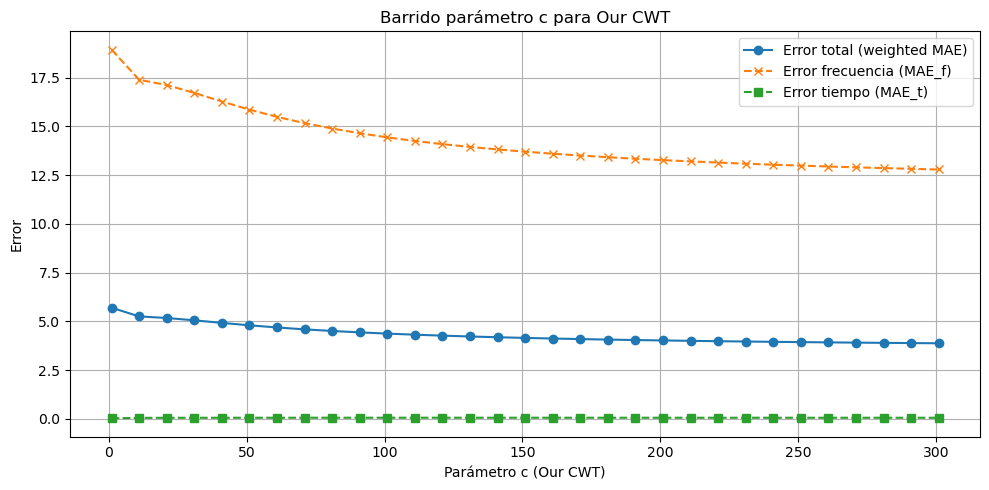


MÍNIMO 1D → parámetro c (Our CWT)
Mejor parámetro c = 301
Error mínimo total = 3.8806
Error mínimo frecuencia = 12.7923
Error mínimo tiempo = 0.0613


In [89]:
params_cwt = np.arange(1, 302, 10)

heatmap_f = np.zeros(len(params_cwt))
heatmap_t = np.zeros(len(params_cwt))
heatmap_total = np.zeros(len(params_cwt))

print("\n==========================================================")
print("        OUR CWT → Barrido 1D parámetro c")
print("==========================================================\n")

for i, c in enumerate(params_cwt):
    print(f"Checking parameter c = {c}")

    try:
        wavelet = f'cmor{c}-1.0'

        # Transformada CWT
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)

        scalogram = np.array(jnp.abs(cwtmatr)**2)

        # --- Instant freq ---
        instant_freq = np.sum(scalogram * freqs[:, None], axis=0) / (np.sum(scalogram, axis=0) + 1e-12)
        instant_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

        # --- Onset/offset ---
        t_on, t_off = get_onset_offset(
            scalogram,
            burst_start,
            burst_duration,
            t,
            fs,
            smooth_sigma,
            plot=False
        )
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        # Métrica total ponderada
        total = w_f * mae_f + w_t * mae_t

    except Exception as e:
        print(f"ERROR parámetro c={c}: {e}")
        mae_f = mae_t = total = np.nan

    heatmap_f[i] = mae_f
    heatmap_t[i] = mae_t
    heatmap_total[i] = total

# -----------------------------------------------------------
# Graficar heatmap (en 1D solo curva)
plt.figure(figsize=(10, 5))
plt.plot(params_cwt, heatmap_total, marker='o', label='Error total (weighted MAE)')
plt.plot(params_cwt, heatmap_f, marker='x', linestyle='--', label='Error frecuencia (MAE_f)')
plt.plot(params_cwt, heatmap_t, marker='s', linestyle='--', label='Error tiempo (MAE_t)')

plt.xlabel('Parámetro c (Our CWT)')
plt.ylabel('Error')
plt.title('Barrido parámetro c para Our CWT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Localizar mínimo
idx_min = np.nanargmin(heatmap_total)
best_c = params_cwt[idx_min]

print("\n==========================================================")
print("MÍNIMO 1D → parámetro c (Our CWT)")
print("==========================================================")
print(f"Mejor parámetro c = {best_c}")
print(f"Error mínimo total = {heatmap_total[idx_min]:.4f}")
print(f"Error mínimo frecuencia = {heatmap_f[idx_min]:.4f}")
print(f"Error mínimo tiempo = {heatmap_t[idx_min]:.4f}")


### Superlet Transform


             SUPERLET → Barrido COMPLETO 3D


===== baseCycle = 1 =====
Checking min order = 1
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 6
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 11
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302

===== baseCycle = 11 =====
Checking min order = 1
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 6
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 15

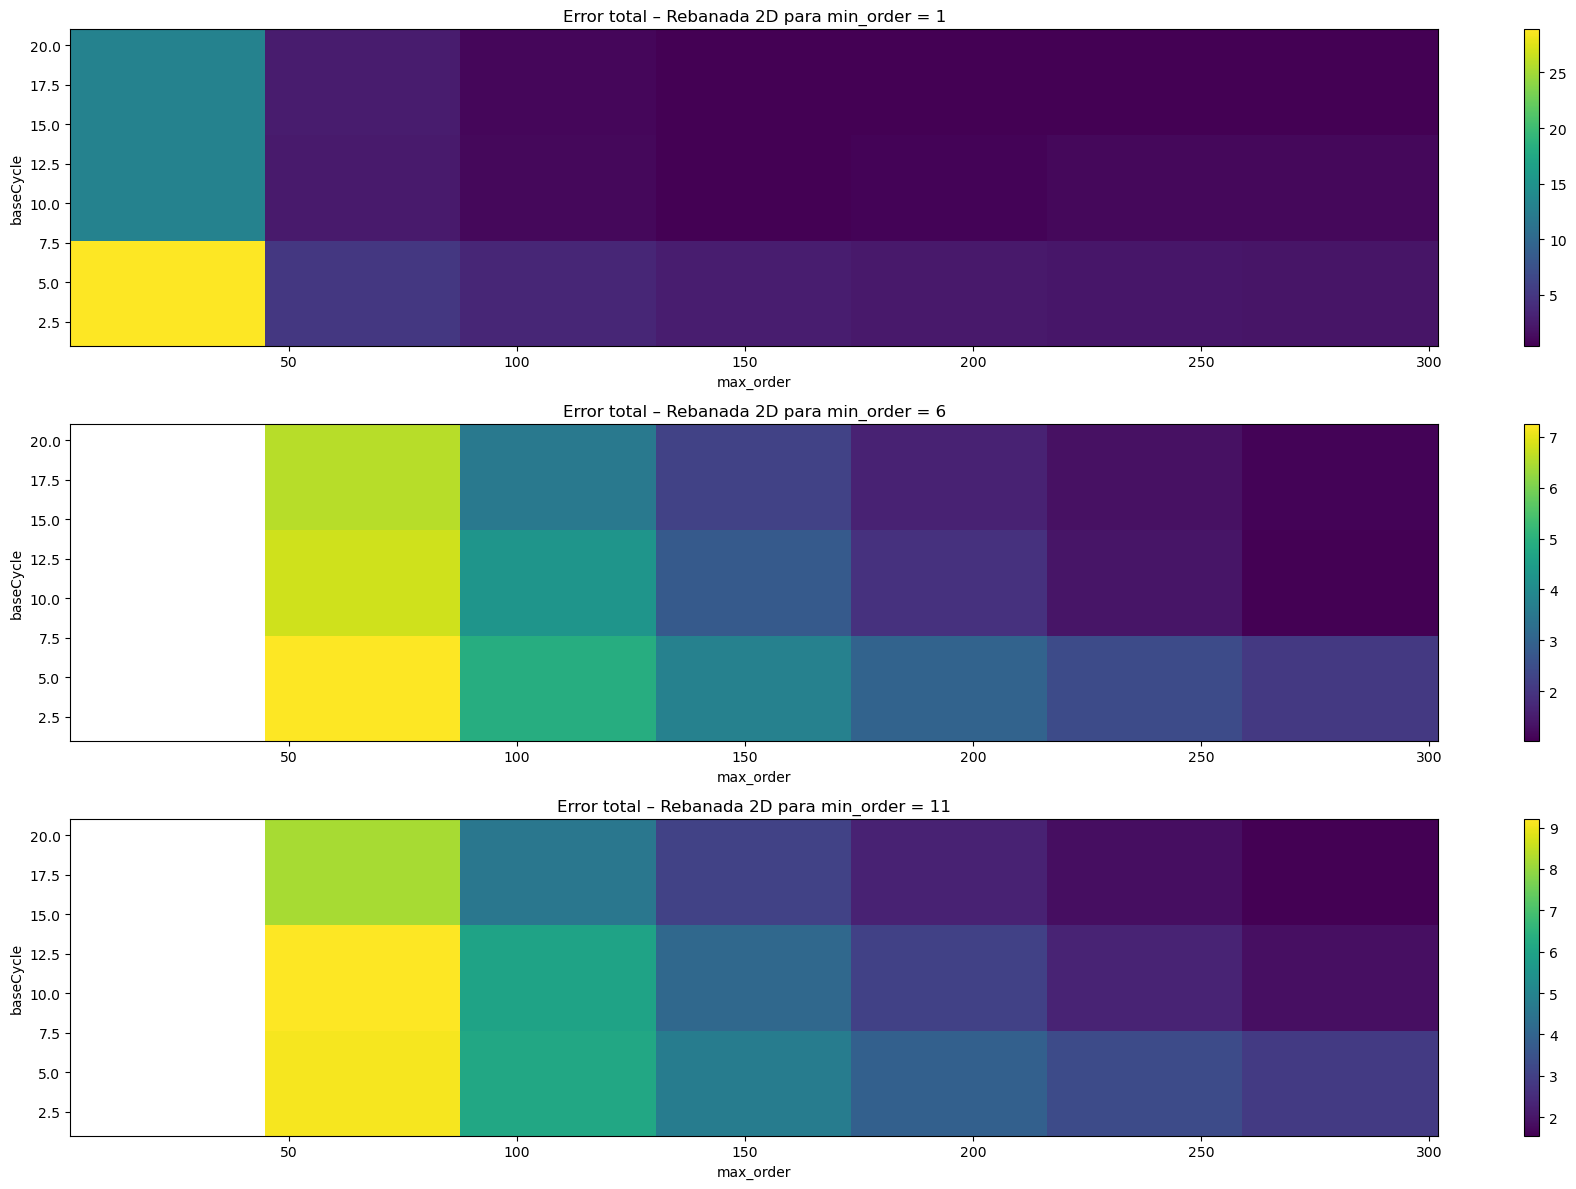

In [31]:
bases_3d = np.arange(1, 22, 10)          # eje baseCycle
min_orders_3d = np.arange(1, 12, 5)      # eje min_order
max_orders_3d = np.arange(2, 303, 50)  # eje max_order

heatmap_3d = np.zeros(
    (len(bases_3d), len(min_orders_3d), len(max_orders_3d))
)

eps = 1e-12

print("\n==========================================================")
print("             SUPERLET → Barrido COMPLETO 3D")
print("==========================================================\n")

# ============================================================
# ================ BUCLE 3D PARA CALCULAR ERRORES =============
# ============================================================

for i, base in enumerate(bases_3d):
    print(f"\n===== baseCycle = {base} =====")
    for k, o_min in enumerate(min_orders_3d):
        print(f'Checking min order = {o_min}')
        for j, o_max in enumerate(max_orders_3d):
            print(f'Checking max order = {o_max}')

            # Evitar max_order < min_order
            if o_max <= o_min:
                heatmap_3d[i, k, j] = np.nan
                continue

            try:
                # --------------------------------------------------
                #                   SUPERLET
                # --------------------------------------------------
                wv, sltRez = superlet.adaptive_superlet_transform(
                    test_signal,
                    freqs,
                    sampling_freq=fs,
                    base_cycle=base,
                    min_order=o_min,
                    max_order=o_max,
                    mode="mul"
                )

                sltRez_scalogram = np.array(jnp.abs(sltRez) ** 2)

                # ========== Instant freq ==========
                instant_freq = np.sum(
                    sltRez_scalogram * freqs[:, None], axis=0
                ) / (np.sum(sltRez_scalogram, axis=0) + eps)

                instant_freq_burst = instant_freq[start_idx:end_idx]
                mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

                # ========== Onset-offset ==========
                t_on, t_off = get_onset_offset(
                    sltRez_scalogram,
                    burst_start,
                    burst_duration,
                    t,
                    fs,
                    smooth_sigma,
                    plot=False
                )
                mae_t, _ = superlet.calculate_mae(
                    (t_on, t_off),
                    (real_t_onset, real_t_offset)
                )

                # ===== Métrica total =====
                total = w_f * mae_f + w_t * mae_t

            except Exception as e:
                print(f"ERROR base={base}, min={o_min}, max={o_max}: {e}")
                total = np.nan

            heatmap_3d[i, k, j] = total

# ============================================================
# ============== LOCALIZAR MÍNIMO GLOBAL 3D ==================
# ============================================================

idx = np.nanargmin(heatmap_3d)
best_i, best_k, best_j = np.unravel_index(idx, heatmap_3d.shape)

best_base = bases_3d[best_i]
best_min  = min_orders_3d[best_k]
best_max  = max_orders_3d[best_j]

print("\n==========================================================")
print("                 MÍNIMO GLOBAL 3D")
print("==========================================================")
print(f"Mejor baseCycle = {best_base}")
print(f"Mejor min_order = {best_min}")
print(f"Mejor max_order = {best_max}")
print(f"Error mínimo    = {heatmap_3d[best_i, best_k, best_j]:.4f}")

# ============================================================
# ===================== REBANADAS 2D =========================
# ============================================================

plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_2d = heatmap_3d[:, k, :]   # baseCycle × max_order

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_2d,
        origin="lower",
        cmap="viridis",
        aspect="auto",
        extent=[
            max_orders_3d[0], max_orders_3d[-1],
            bases_3d[0], bases_3d[-1]
        ]
    )

    ax.set_title(f"Error total – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()




        SUPERLET → Barrido 2D baseCycle × max_order

Checking base cycle = 1
Checking max order = 10
Checking max order = 60
Checking max order = 110
Checking max order = 160
Checking max order = 210
Checking max order = 260
Checking max order = 310
Checking max order = 360
Checking max order = 410
Checking max order = 460
Checking max order = 510
Checking max order = 560
Checking base cycle = 11
Checking max order = 10
Checking max order = 60
Checking max order = 110
Checking max order = 160
Checking max order = 210
Checking max order = 260
Checking max order = 310
Checking max order = 360
Checking max order = 410
Checking max order = 460
Checking max order = 510
Checking max order = 560
Checking base cycle = 21
Checking max order = 10
Checking max order = 60
Checking max order = 110
Checking max order = 160
Checking max order = 210
Checking max order = 260
Checking max order = 310
Checking max order = 360
Checking max order = 410
Checking max order = 460
Checking max order = 510
Che

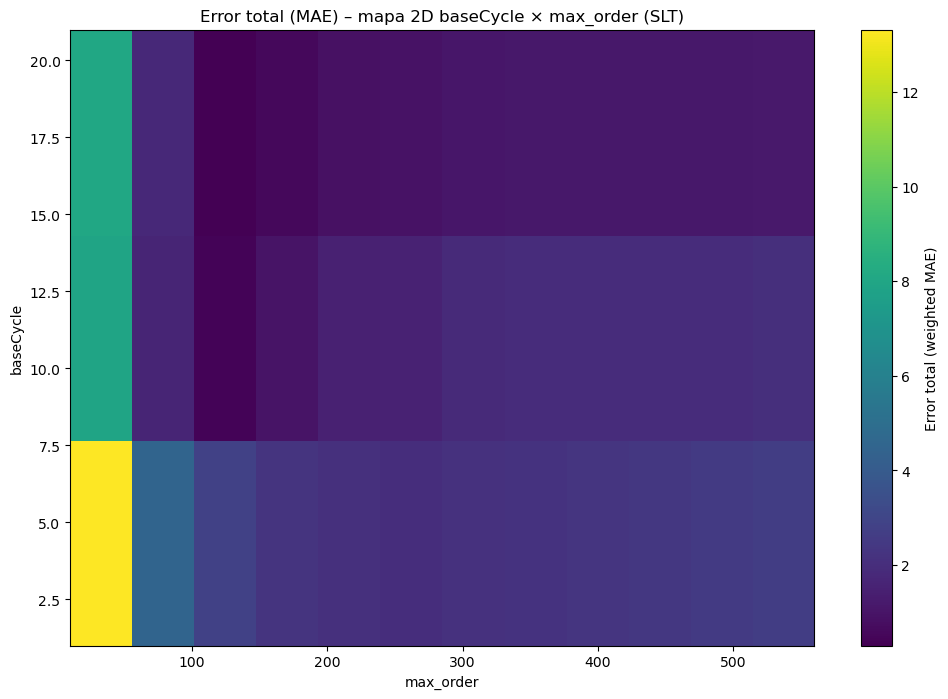


MÍNIMO 2D → interacción baseCycle × max_order (SLT)
Mejor baseCycle = 21
Mejor min_order = 1.00 (fijo)
Mejor max_order = 110.00
Error mínimo    = 0.2970

Rango sugerido para optimización bayesiana:
baseCycle: [1, 21]
min_order: [0.90, 1.10] (fijo en barrido)
max_order: [109.50, 110.50]


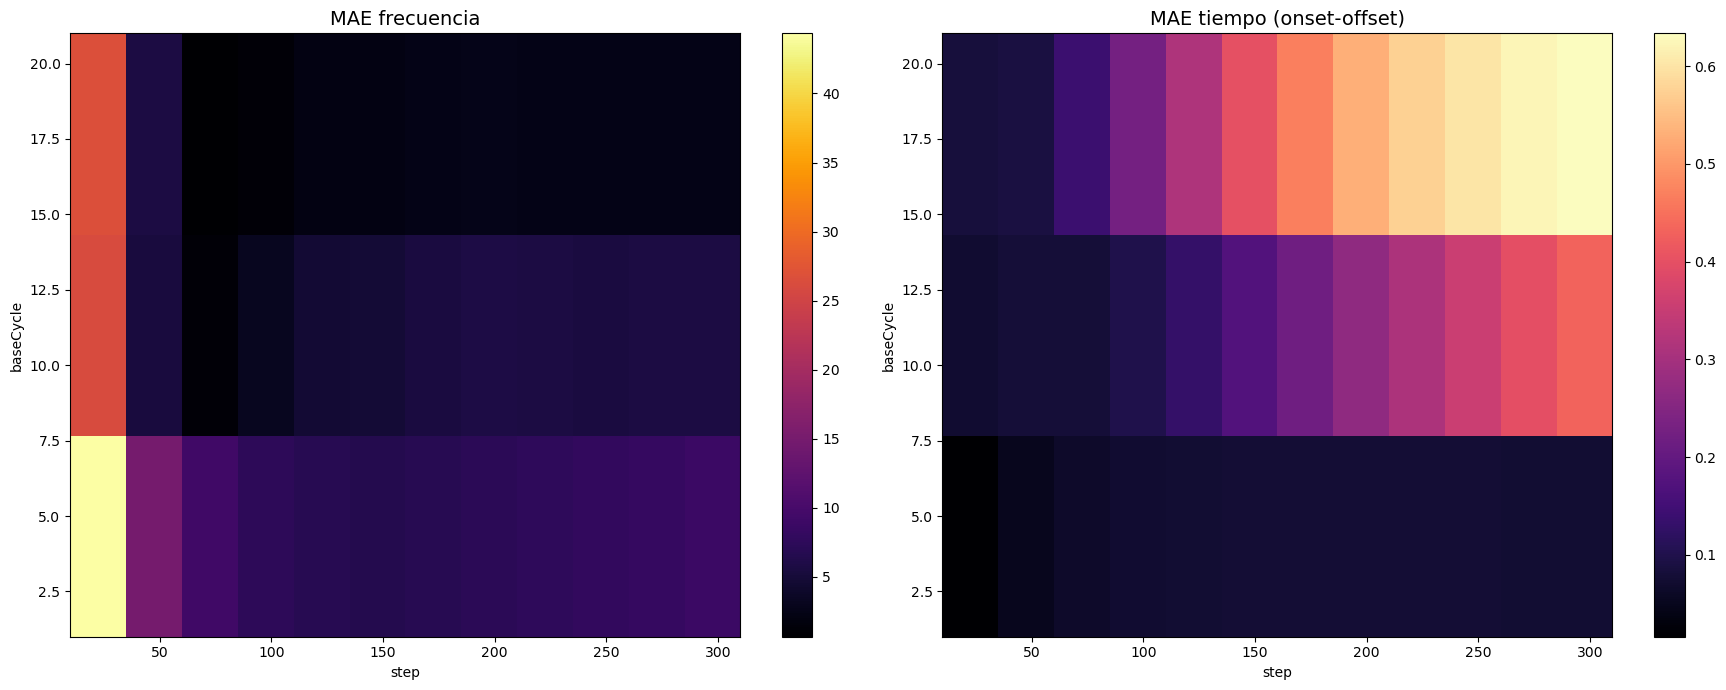

In [57]:
bases_2d = np.arange(1, 31, 10)
max_orders_2d = np.arange(10, 601, 50)
fixed_min_order = 1.0                      # fijo el min_order (ajusta si quieres)

heatmap_total = np.zeros((len(bases_2d), len(max_orders_2d)))
heatmap_f = np.zeros_like(heatmap_total)
heatmap_t = np.zeros_like(heatmap_total)

print("\n==========================================================")
print("        SUPERLET → Barrido 2D baseCycle × max_order")
print("==========================================================\n")

for i, base in enumerate(bases_2d):
    print("==========================================================")
    print(f"Checking base cycle = {base}")
    for j, o_max in enumerate(max_orders_2d):
        print(f"Checking max order = {o_max}")

        o_min = fixed_min_order

        # Evitar max_order menor que min_order (no tiene sentido)
        if o_max <= o_min:
            heatmap_f[i, j] = np.nan
            heatmap_t[i, j] = np.nan
            heatmap_total[i, j] = np.nan
            continue

        try:
            # --- SUPERLET ---
            wv, sltRez = superlet.adaptive_superlet_transform(
                test_signal,
                freqs,
                sampling_freq=fs,
                base_cycle=base,
                min_order=o_min,
                max_order=o_max,
                mode="mul"
            )

            sltRez_scalogram = np.array(jnp.abs(sltRez)**2)

            # --- Instant freq ---
            instant_freq = np.sum(sltRez_scalogram * freqs[:, None], axis=0) / (np.sum(sltRez_scalogram, axis=0) + eps)
            instant_freq_burst = instant_freq[start_idx:end_idx]
            mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

            # --- Onset/offset ---
            t_on, t_off = get_onset_offset(
                sltRez_scalogram,
                burst_start,
                burst_duration,
                t,
                fs,
                smooth_sigma,
                plot=False
            )
            mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

            # --- Métrica total ponderada ---
            total = w_f * mae_f + w_t * mae_t

        except Exception as e:
            print(f"ERROR base={base}, max_order={o_max}: {e}")
            mae_f = mae_t = total = np.nan

        heatmap_f[i, j] = mae_f
        heatmap_t[i, j] = mae_t
        heatmap_total[i, j] = total


# ============================================================
# ======================== HEATMAP 2D =========================
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_total, origin="lower", cmap="viridis",
               extent=[max_orders_2d[0], max_orders_2d[-1], bases_2d[0], bases_2d[-1]],
               aspect="auto")

plt.colorbar(im, ax=ax, label="Error total (weighted MAE)")
ax.set_title("Error total (MAE) – mapa 2D baseCycle × max_order (SLT)")
ax.set_xlabel("max_order")
ax.set_ylabel("baseCycle")

plt.show()

# ==================== LOCALIZAR MÍNIMO =======================

idx = np.nanargmin(heatmap_total)
best_i, best_j = np.unravel_index(idx, heatmap_total.shape)

best_base_2d = bases_2d[best_i]
best_max_order_2d = max_orders_2d[best_j]
best_min_order_2d = fixed_min_order

print("\n==========================================================")
print("MÍNIMO 2D → interacción baseCycle × max_order (SLT)")
print("==========================================================")
print(f"Mejor baseCycle = {best_base_2d}")
print(f"Mejor min_order = {best_min_order_2d:.2f} (fijo)")
print(f"Mejor max_order = {best_max_order_2d:.2f}")
print(f"Error mínimo    = {heatmap_total[best_i, best_j]:.4f}")

# ==================== SUGERENCIA RANGO PARA OPTIMIZACIÓN BAYESIANA ================

base_min = max(bases_2d[0], best_base_2d - 20)
base_max = min(bases_2d[-1], best_base_2d + 20)

min_order_min = best_min_order_2d - 0.1
min_order_max = best_min_order_2d + 0.1

max_order_min = max(best_min_order_2d + 0.1, best_max_order_2d - 0.5)
max_order_max = best_max_order_2d + 0.5

print("\nRango sugerido para optimización bayesiana:")
print(f"baseCycle: [{base_min}, {base_max}]")
print(f"min_order: [{min_order_min:.2f}, {min_order_max:.2f}] (fijo en barrido)")
print(f"max_order: [{max_order_min:.2f}, {max_order_max:.2f}]")

fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# -------------------- HEATMAP MAE FRECUENCIA --------------------
im1 = axs[0].imshow(
    heatmap_f,
    origin="lower",
    cmap="inferno",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[0].set_title("MAE frecuencia", fontsize=14)
axs[0].set_xlabel("step")
axs[0].set_ylabel("baseCycle")
plt.colorbar(im1, ax=axs[0])

# -------------------- HEATMAP MAE TIEMPO ------------------------
im2 = axs[1].imshow(
    heatmap_t,
    origin="lower",
    cmap="magma",
    extent=[steps_2d[0], steps_2d[-1], bases_2d[0], bases_2d[-1]],
    aspect="auto"
)
axs[1].set_title("MAE tiempo (onset-offset)", fontsize=14)
axs[1].set_xlabel("step")
axs[1].set_ylabel("baseCycle")
plt.colorbar(im2, ax=axs[1])

plt.tight_layout()
plt.show()

# BAYESIAN OPTIMIZATION

# OPTIMIZE SINGULAR SUPERLET

In [20]:
import optuna

def objective_sst(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    base = trial.suggest_int('base_cycle', 3, 83)
    step = trial.suggest_int('step', 5, 100)
    

    # if min_o > max_o:
    #     return float('inf'), float('inf')

    try:
        sstRez, o_min, o_max = sst.sst(test_signal, freqs, fs, base, norm, step) #Ya es el escalograma
    
        instant_freq = np.sum(sstRez * freqs[:, None], axis=0) / (np.sum(sstRez, axis=0) + eps)
        energia_temporal = sstRez
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t[first_indices]
        t_offset = t[last_indices]
        
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))
    
        return mae_f, mae_t

    except Exception as e:
        return float('inf'), float('inf')

study_sst = optuna.create_study(directions=["minimize", "minimize"])
study_sst.optimize(objective_sst, n_trials=200)

[I 2025-12-11 15:44:42,548] A new study created in memory with name: no-name-54dc17ee-e2ca-4f93-aa33-a55b03291707
[I 2025-12-11 15:44:45,188] Trial 0 finished with values: [18.046137135201143, 0.08459937723868446] and parameters: {'base_cycle': 27, 'step': 48}.
[I 2025-12-11 15:44:49,174] Trial 1 finished with values: [26.328224064736443, 0.08461209703679584] and parameters: {'base_cycle': 69, 'step': 94}.
[I 2025-12-11 15:44:52,868] Trial 2 finished with values: [25.388266728712683, 0.08487094492836209] and parameters: {'base_cycle': 62, 'step': 89}.
[I 2025-12-11 15:44:57,537] Trial 3 finished with values: [11.026878122960573, 0.08571553952295669] and parameters: {'base_cycle': 25, 'step': 19}.
[I 2025-12-11 15:45:00,386] Trial 4 finished with values: [24.16348009246396, 0.08231744545750569] and parameters: {'base_cycle': 46, 'step': 84}.
[I 2025-12-11 15:45:03,037] Trial 5 finished with values: [25.302364361306196, 0.08223031484044285] and parameters: {'base_cycle': 45, 'step': 92}.

In [21]:
# Obtener los trials únicos de la frontera de Pareto, según combinación de parámetros
seen = set()
unique_best = []

for trial in sorted(study_sst.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

# Imprimir configuraciones únicas del Pareto front
print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    mae_f, mae_t = trial.values
    print(f"{i}. base_cycle={params['base_cycle']}, step={params['step']} → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

# Obtener el mejor resultado único (mínima suma de errores)
# best = min(unique_best, key=lambda x: sum(x.values))
best = min(unique_best, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación única (f + t mínimas):")
print(f"base_cycle={best.params['base_cycle']}, step={best.params['step']}")
print(f"MAE_f={best.values[0]:.4f}, MAE_t={best.values[1]:.4f}")

# Obtener el trial con menor error solo en frecuencia (MAE_f)
best_f = min(study_sst.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"base_cycle={best_f.params['base_cycle']}, step={best_f.params['step']}")
print(f"MAE_f={best_f.values[0]:.4f}, MAE_t={best_f.values[1]:.4f}")

# Obtener el trial con menor error solo en tiempo (MAE_t)
best_t = min(study_sst.trials, key=lambda x: x.values[1])
print("\n⚡ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"base_cycle={best_t.params['base_cycle']}, step={best_t.params['step']}")
print(f"MAE_f={best_t.values[0]:.4f}, MAE_t={best_t.values[1]:.4f}")

# Visualización rápida del pareto front
mae_f_vals_sst = [b.values[0] for b in study_sst.trials]
mae_t_vals_sst = [b.values[1] for b in study_sst.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. base_cycle=27, step=9 → MAE_f=7.5856, MAE_t=0.0807
2. base_cycle=13, step=8 → MAE_f=7.1779, MAE_t=0.0875
3. base_cycle=28, step=14 → MAE_f=9.7788, MAE_t=0.0746

🎯 Mejor combinación única (f + t mínimas):
base_cycle=27, step=9
MAE_f=7.5856, MAE_t=0.0807

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
base_cycle=61, step=5
MAE_f=5.0161, MAE_t=0.1848

⚡ Mejor combinación solo en tiempo (mínimo MAE_t):
base_cycle=4, step=98
MAE_f=47.1666, MAE_t=0.0321


# OPTIMIZE ADAPTIVE WAVELET PARAMETERS

In [22]:
import optuna

def objective_cwt(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    base = trial.suggest_int('base_cycle', 3,83)
    step = trial.suggest_int('step', 5, 100)
    

    # if min_o > max_o:
    #     return float('inf'), float('inf')

    # try:
    cwtRez = cwt.cwt(test_signal, freqs, fs, base, norm, step)

    instant_freq = np.sum(cwtRez * freqs[:, None], axis=0) / (np.sum(cwtRez, axis=0) + eps)
    energia_temporal = cwtRez

    first_indices = []
    last_indices = []
    
    for row in energia_temporal:
        first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
    
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

    return mae_f, mae_t

    # except Exception as e:
    #     return float('inf'), float('inf')

study_cwt = optuna.create_study(directions=["minimize", "minimize"])
study_cwt.optimize(objective_cwt, n_trials=200)

[I 2025-12-11 16:08:22,736] A new study created in memory with name: no-name-09dcc877-2550-4a5f-8913-57d32792467d
[I 2025-12-11 16:08:30,576] Trial 0 finished with values: [7.2758822197350925, 0.2617782150561706] and parameters: {'base_cycle': 19, 'step': 8}.
[I 2025-12-11 16:08:43,850] Trial 1 finished with values: [16.254800421023745, 0.49476771104689027] and parameters: {'base_cycle': 81, 'step': 22}.
[I 2025-12-11 16:08:46,184] Trial 2 finished with values: [18.613621429623628, 0.10853962725903615] and parameters: {'base_cycle': 26, 'step': 49}.
[I 2025-12-11 16:08:47,120] Trial 3 finished with values: [20.842750549966812, 0.09326887363643763] and parameters: {'base_cycle': 13, 'step': 74}.
[I 2025-12-11 16:09:08,143] Trial 4 finished with values: [9.683671479756402, 0.7099672973990556] and parameters: {'base_cycle': 64, 'step': 10}.
[I 2025-12-11 16:09:13,555] Trial 5 finished with values: [21.601613801617233, 0.17242385928850537] and parameters: {'base_cycle': 60, 'step': 47}.
[I

In [23]:
# Obtener los trials únicos de la frontera de Pareto, según combinación de parámetros
seen = set()
unique_best = []

for trial in sorted(study_cwt.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

# Imprimir configuraciones únicas del Pareto front
print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    mae_f, mae_t = trial.values
    print(f"{i}. base_cycle={params['base_cycle']}, step={params['step']} → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

# Obtener el mejor resultado único (mínima suma de errores)
best = min(unique_best, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
# best = min(unique_best, key=lambda x: sum(x.values))
print("\n🎯 Mejor combinación única (f + t mínimas):")
print(f"base_cycle={best.params['base_cycle']}, step={best.params['step']}")
print(f"MAE_f={best.values[0]:.4f}, MAE_t={best.values[1]:.4f}")

# Obtener el trial con menor error solo en frecuencia (MAE_f)
best_f = min(study_cwt.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"base_cycle={best_f.params['base_cycle']}, step={best_f.params['step']}")
print(f"MAE_f={best_f.values[0]:.4f}, MAE_t={best_f.values[1]:.4f}")

# Obtener el trial con menor error solo en tiempo (MAE_t)
best_t = min(study_cwt.trials, key=lambda x: x.values[1])
print("\n⚡ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"base_cycle={best_t.params['base_cycle']}, step={best_t.params['step']}")
print(f"MAE_f={best_t.values[0]:.4f}, MAE_t={best_t.values[1]:.4f}")

# Visualización rápida del pareto front
mae_f_vals_adaptive_cwt = [b.values[0] for b in study_cwt.trials]
mae_t_vals_adaptive_cwt = [b.values[1] for b in study_cwt.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. base_cycle=6, step=19 → MAE_f=10.6117, MAE_t=0.0984
2. base_cycle=3, step=22 → MAE_f=13.5410, MAE_t=0.0856
3. base_cycle=10, step=8 → MAE_f=6.4130, MAE_t=0.1310

🎯 Mejor combinación única (f + t mínimas):
base_cycle=6, step=19
MAE_f=10.6117, MAE_t=0.0984

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
base_cycle=16, step=5
MAE_f=5.3362, MAE_t=0.3706

⚡ Mejor combinación solo en tiempo (mínimo MAE_t):
base_cycle=3, step=69
MAE_f=22.6952, MAE_t=0.0621


# OPTIMIZE OUR CWT

In [37]:
def objective_our_cwt(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    # Optimizar número de ciclos de la wavelet entre 1 y 100
    c = trial.suggest_int('num_cycles', 1, 300)
    wavelet = f'cmor{c}-1.0'

    try:
        # Transformada CWT
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)

        # Escalograma al cuadrado
        scalogram_2 = np.array(jnp.abs(cwtmatr)**2)

        # Frecuencia instantánea promedio
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)

        # Energía total por tiempo
        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t[first_indices]
        t_offset = t[last_indices]

        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        # MAE frecuencia
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)

        # MAE tiempo
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        # print(f"[Trial {trial.number}] c={c} → MAE_f: {mae_f:.4f}, MAE_t: {mae_t:.4f}")

        return mae_f, mae_t

    except Exception as e:
        print(f"[Trial {trial.number}] ERROR: {e}")
        return float('inf'), float('inf')


study_our_cwt = optuna.create_study(directions=["minimize", "minimize"])
study_our_cwt.optimize(objective_our_cwt, n_trials=200)

[I 2025-11-26 13:44:12,800] A new study created in memory with name: no-name-db1b8ade-cbb1-42ca-84e0-7dec802b4553
[I 2025-11-26 13:44:13,058] Trial 0 finished with values: [6.808334839734512, 0.061277627401497885] and parameters: {'num_cycles': 294}.
[I 2025-11-26 13:44:13,299] Trial 1 finished with values: [6.247970779954932, 0.06264150775398893] and parameters: {'num_cycles': 161}.
[I 2025-11-26 13:44:13,547] Trial 2 finished with values: [6.629153213843261, 0.06157081874796483] and parameters: {'num_cycles': 241}.
[I 2025-11-26 13:44:13,794] Trial 3 finished with values: [5.728030104159325, 0.06301260786388799] and parameters: {'num_cycles': 89}.
[I 2025-11-26 13:44:14,041] Trial 4 finished with values: [6.082991590539811, 0.06259094655649625] and parameters: {'num_cycles': 135}.
[I 2025-11-26 13:44:14,284] Trial 5 finished with values: [5.423536665478227, 0.06045179450911754] and parameters: {'num_cycles': 44}.
[I 2025-11-26 13:44:14,521] Trial 6 finished with values: [6.5774612901

In [119]:
seen = set()
unique_best = []

for trial in sorted(study_our_cwt.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    print(f"{i}. {params} → MAE_f = {trial.values[0]:.4f}, MAE_t = {trial.values[1]:.4f}")

best_weighted = min(study_our_cwt.trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):")
print(f"{best_weighted.params} → "
      f"MAE_f = {best_weighted.values[0]:.4f}, MAE_t = {best_weighted.values[1]:.4f}, "
      f"Score = {w_f * best_weighted.values[0] + w_t * best_weighted.values[1]:.4f}")

best_f = min(study_our_cwt.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"{best_f.params} → MAE_f = {best_f.values[0]:.4f}, MAE_t = {best_f.values[1]:.4f}")

best_t = min(study_our_cwt.trials, key=lambda x: x.values[1])
print("\n⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"{best_t.params} → MAE_f = {best_t.values[0]:.4f}, MAE_t = {best_t.values[1]:.4f}")


# --- Visualización del frente de Pareto ---
mae_f_vals_our_wavelet = [b.values[0] for b in study_our_cwt.trials]
mae_t_vals_our_wavelet = [b.values[1] for b in study_our_cwt.trials]



🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. {'num_cycles': 39} → MAE_f = 5.4307, MAE_t = 0.0599
2. {'num_cycles': 38} → MAE_f = 5.4367, MAE_t = 0.0599
3. {'num_cycles': 33} → MAE_f = 5.4877, MAE_t = 0.0597

🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):
{'num_cycles': 39} → MAE_f = 5.4307, MAE_t = 0.0599, Score = 0.0868

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
{'num_cycles': 43} → MAE_f = 5.4232, MAE_t = 0.0604

⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):
{'num_cycles': 1} → MAE_f = 15.4446, MAE_t = 0.0334


# OPTIMIZE SUPERLET PARAMETERS

In [39]:
import optuna

def objective_superlet(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    base = trial.suggest_int('base_cycle', 8, 20)
    min_o = trial.suggest_int('min_order', 1, 10)
    max_o = trial.suggest_int('max_order', 50, 150)

    if min_o > max_o:
        return float('inf'), float('inf')

    try:
        _, scalogram = superlet.adaptive_superlet_transform(
            test_signal, freqs, sampling_freq=fs,
            base_cycle=base, min_order=min_o,
            max_order=max_o, mode="mul"
        )

        scalogram_2 = np.abs(scalogram)**2
        instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t[first_indices]
        t_offset = t[last_indices]
        
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        return mae_f, mae_t

    except Exception as e:
        return float('inf'), float('inf')

study_superlet = optuna.create_study(directions=["minimize", "minimize"])
study_superlet.optimize(objective_superlet, n_trials=200)

[I 2025-11-26 13:48:32,005] A new study created in memory with name: no-name-e10aba87-09b2-4b33-b416-ee23bc013bfc
[I 2025-11-26 13:48:39,160] Trial 0 finished with values: [17.541498083894414, 0.12616576949690655] and parameters: {'base_cycle': 17, 'min_order': 9, 'max_order': 88}.
[I 2025-11-26 13:48:45,156] Trial 1 finished with values: [18.78099574854022, 0.10151321078231847] and parameters: {'base_cycle': 12, 'min_order': 9, 'max_order': 93}.
[I 2025-11-26 13:48:54,208] Trial 2 finished with values: [6.117443492250635, 0.1721491116492999] and parameters: {'base_cycle': 20, 'min_order': 3, 'max_order': 120}.
[I 2025-11-26 13:49:02,074] Trial 3 finished with values: [11.09823615410719, 0.1522982767217519] and parameters: {'base_cycle': 19, 'min_order': 6, 'max_order': 108}.
[I 2025-11-26 13:49:09,902] Trial 4 finished with values: [13.198255645578374, 0.08845411205633344] and parameters: {'base_cycle': 8, 'min_order': 6, 'max_order': 111}.
[I 2025-11-26 13:49:17,716] Trial 5 finished

In [122]:
# Obtener los trials únicos de la frontera de Pareto, según combinación de parámetros
seen = set()
unique_best = []

for trial in sorted(study_superlet.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

# Imprimir configuraciones únicas del Pareto front
print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    mae_f, mae_t = trial.values
    print(f"{i}. base_cycle={params['base_cycle']}, min_order={params['min_order']}, max_order={params['max_order']} → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

# Obtener el mejor resultado único (mínima suma de errores)
# best = min(unique_best, key=lambda x: sum(x.values))
best = min(unique_best, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación única (f + t mínimas):")
print(f"base_cycle={best.params['base_cycle']}, min_order={best.params['min_order']}, max_order={best.params['max_order']}")
print(f"MAE_f={best.values[0]:.4f}, MAE_t={best.values[1]:.4f}")

# Obtener el trial con menor error solo en frecuencia (MAE_f)
best_f = min(study_superlet.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"base_cycle={best_f.params['base_cycle']}, min_order={best_f.params['min_order']}, max_order={best_f.params['max_order']}")
print(f"MAE_f={best_f.values[0]:.4f}, MAE_t={best_f.values[1]:.4f}")

# Obtener el trial con menor error solo en tiempo (MAE_t)
best_t = min(study_superlet.trials, key=lambda x: x.values[1])
print("\n⚡ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"base_cycle={best_t.params['base_cycle']}, min_order={best_t.params['min_order']}, max_order={best_t.params['max_order']}")
print(f"MAE_f={best_t.values[0]:.4f}, MAE_t={best_t.values[1]:.4f}")


# Visualización rápida del pareto front
mae_f_vals_superlet = [b.values[0] for b in study_superlet.trials]
mae_t_vals_superlet = [b.values[1] for b in study_superlet.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. base_cycle=8, min_order=1, max_order=118 → MAE_f=2.8959, MAE_t=0.0896
2. base_cycle=10, min_order=1, max_order=126 → MAE_f=1.9205, MAE_t=0.0951
3. base_cycle=10, min_order=1, max_order=143 → MAE_f=1.4014, MAE_t=0.1006

🎯 Mejor combinación única (f + t mínimas):
base_cycle=8, min_order=1, max_order=118
MAE_f=2.8959, MAE_t=0.0896

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
base_cycle=17, min_order=1, max_order=142
MAE_f=1.2419, MAE_t=0.1617

⚡ Mejor combinación solo en tiempo (mínimo MAE_t):
base_cycle=8, min_order=4, max_order=103
MAE_f=10.3458, MAE_t=0.0873


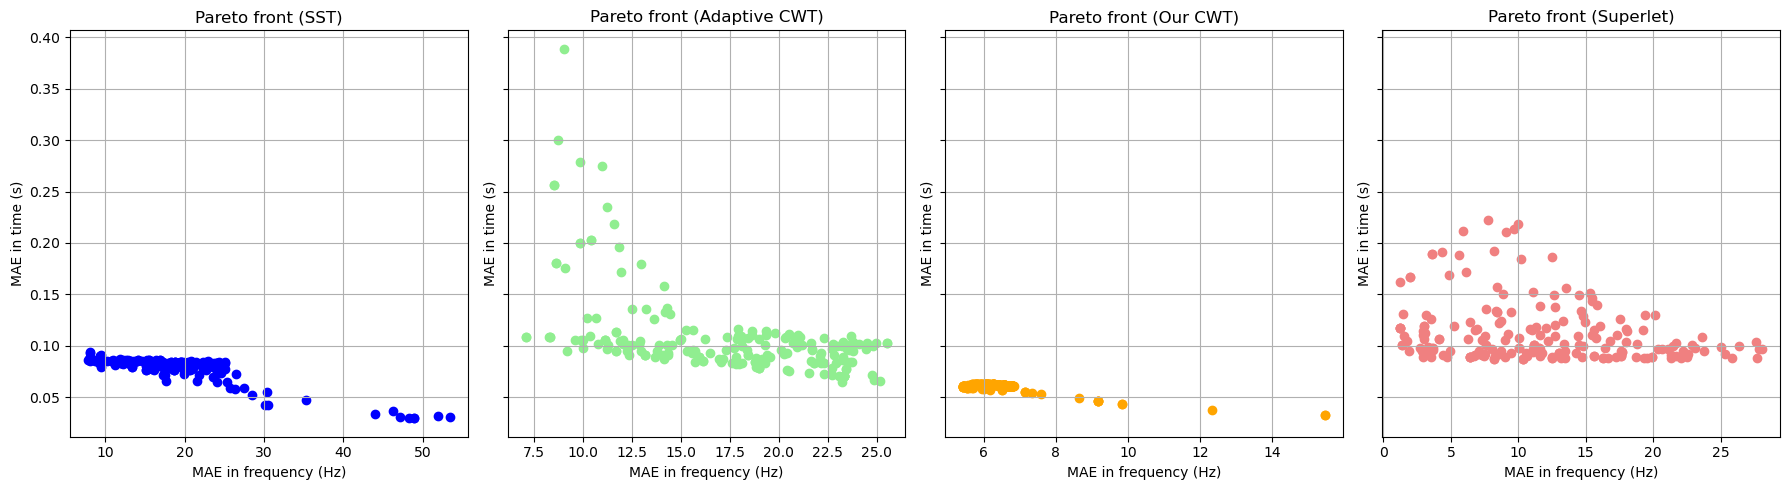

In [94]:
import matplotlib.pyplot as plt

# Calcula los límites a partir de los datos de Superlet
# x_min = min(mae_f_vals_superlet)
# x_max = max(mae_f_vals_superlet)
# y_min = min(mae_t_vals_superlet)
# y_max = max(mae_t_vals_superlet)
# 
# # Agrega márgenes
# x_margin = (x_max - x_min) * 0.05
# y_margin = (y_max - y_min) * 0.05
# xlim = (x_min - x_margin, x_max + x_margin)
# ylim = (y_min - y_margin, y_max + y_margin)

# Crear figura con 3 subplots en una fila
fig, axs = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# Singular Superlet
axs[0].scatter(mae_f_vals_sst, mae_t_vals_sst, c='blue')
axs[0].set_title("Pareto front (SST)")
axs[0].set_xlabel("MAE in frequency (Hz)")
axs[0].set_ylabel("MAE in time (s)")
# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)
# axs[0].set_xlim(0,30)
# axs[0].set_ylim(0,0.16)
axs[0].grid(True)

# Wavelet
axs[1].scatter(mae_f_vals_adaptive_cwt, mae_t_vals_adaptive_cwt, c='lightgreen')
axs[1].set_title("Pareto front (Adaptive CWT)")
axs[1].set_xlabel("MAE in frequency (Hz)")
axs[1].set_ylabel("MAE in time (s)")
# axs[1].set_xlim(0,30)
# axs[1].set_ylim(0,0.16)
axs[1].grid(True)

# Wavelet
axs[2].scatter(mae_f_vals_our_wavelet, mae_t_vals_our_wavelet, c='orange')
axs[2].set_title("Pareto front (Our CWT)")
axs[2].set_xlabel("MAE in frequency (Hz)")
axs[2].set_ylabel("MAE in time (s)")
# axs[1].set_xlim(0,30)
# axs[1].set_ylim(0,0.16)
axs[2].grid(True)

# Superlet
axs[3].scatter(mae_f_vals_superlet, mae_t_vals_superlet, c='lightcoral')
axs[3].set_title("Pareto front (Superlet)")
axs[3].set_xlabel("MAE in frequency (Hz)")
axs[3].set_ylabel("MAE in time (s)")
# axs[2].set_xlim(0,30)
# axs[2].set_ylim(0,0.16)
# axs[2].set_ylim(ylim)
axs[3].grid(True)

# Ajustar espacio
plt.tight_layout()
plt.show()


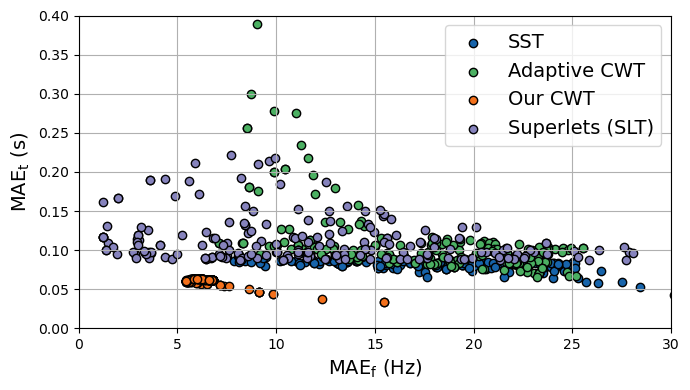

In [98]:
# Asumiendo que ya tienes los resultados de cada uno:
# listas de tuplas/lists: (mae_f, mae_t) para cada trial exitoso

colores_base = {                                 
    "SST": plt.colormaps["Blues"],              
    "Adaptive Wavelet": plt.colormaps["Greens"],          
    "Our Wavelet": plt.colormaps["Oranges"],   
    "Superlet": plt.colormaps["Purples"],    
}        

sst_vals = [(trial.values[0], trial.values[1]) for trial in study_sst.trials]
wavelet_vals = [(trial.values[0], trial.values[1]) for trial in study_cwt.trials]
our_wavelet_vals = [(trial.values[0], trial.values[1]) for trial in study_our_cwt.trials]
superlet_vals = [(trial.values[0], trial.values[1]) for trial in study_superlet.trials]

# Separar coordenadas
stft_f, stft_t = zip(*sst_vals)
wavelet_f, wavelet_t = zip(*wavelet_vals)
our_wavelet_f, our_wavelet_t = zip(*our_wavelet_vals)
superlet_f, superlet_t = zip(*superlet_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(stft_f, stft_t, color=colores_base["SST"](0.8), label='SST', edgecolor='black')
plt.scatter(wavelet_f, wavelet_t, color=colores_base["Adaptive Wavelet"](0.6), label='Adaptive CWT', edgecolor='black')
plt.scatter(our_wavelet_f, our_wavelet_t, color=colores_base["Our Wavelet"](0.6), label='Our CWT', edgecolor='black')
plt.scatter(superlet_f, superlet_t, color=colores_base["Superlet"](0.6), label='Superlets (SLT)', edgecolor='black')

plt.xticks(np.arange(0, 31, 5))

plt.ylim(0,0.4)
plt.xlim(0,30)

plt.xlabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
# plt.title("Pareto front (all values)", fontsize=fontsize_title)
plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()
plt.show()


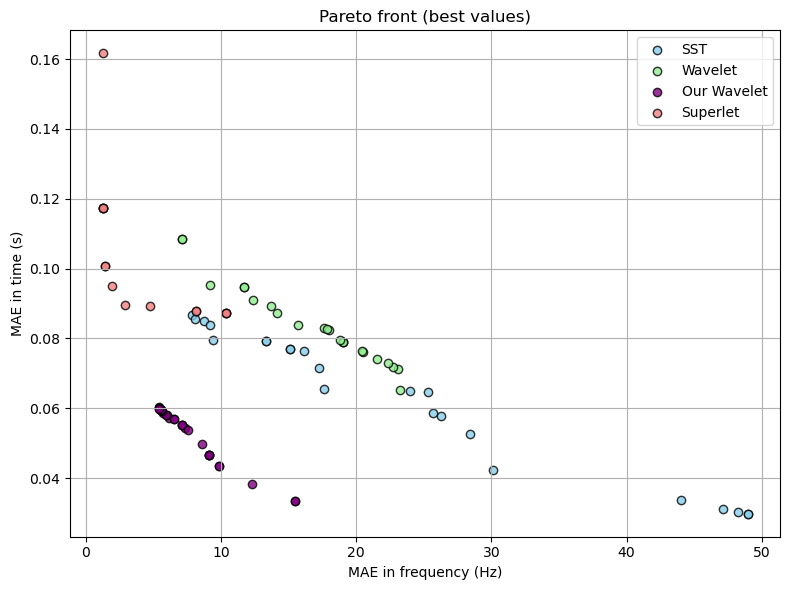

In [99]:
# Asumiendo que ya tienes los resultados de cada uno:
# listas de tuplas/lists: (mae_f, mae_t) para cada trial exitoso
sst_vals = [(trial.values[0], trial.values[1]) for trial in study_sst.best_trials]
wavelet_vals = [(trial.values[0], trial.values[1]) for trial in study_cwt.best_trials]
our_wavelet_vals = [(trial.values[0], trial.values[1]) for trial in study_our_cwt.best_trials]
superlet_vals = [(trial.values[0], trial.values[1]) for trial in study_superlet.best_trials]

# Separar coordenadas
stft_f, stft_t = zip(*sst_vals)
wavelet_f, wavelet_t = zip(*wavelet_vals)
our_wavelet_f, our_wavelet_t = zip(*our_wavelet_vals)
superlet_f, superlet_t = zip(*superlet_vals)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(stft_f, stft_t, color='skyblue', label='SST', edgecolor='black', alpha=0.8)
plt.scatter(wavelet_f, wavelet_t, color='lightgreen', label='Wavelet', edgecolor='black', alpha=0.8)
plt.scatter(our_wavelet_f, our_wavelet_t, color='purple', label='Our Wavelet', edgecolor='black', alpha=0.8)
plt.scatter(superlet_f, superlet_t, color='lightcoral', label='Superlet', edgecolor='black', alpha=0.8)

plt.xlabel("MAE in frequency (Hz)")
plt.ylabel("MAE in time (s)")
plt.title("Pareto front (best values)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# RANDOM SEARCH

# SST

In [100]:
import numpy as np
import random

random_trials_sst = []
total_trials = 200
successful_trials = 0

print(f"\n🔍 Iniciando Random Search para SST con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):

    # === PARÁMETROS DEL SST ===
    base = random.randint(3, 33)      # base_cycle (igual rango que Optuna)
    step = random.randint(10, 100)    # step       (igual rango)

    print(f"🎲 Trial {i+1}/{total_trials}: base_cycle={base}, step={step}...", end=" ")

    try:
        # ==========================
        #        CÁLCULO SST
        # ==========================
        sstRez, o_min, o_max = sst.sst(
            test_signal,
            freqs,
            fs,
            base,
            norm,
            step
        )

        # ==========================
        #    INST FREQ
        # ==========================
        instant_freq = np.sum(sstRez * freqs[:, None], axis=0) / (np.sum(sstRez, axis=0) + eps)
        energia_temporal = sstRez

        first_indices = []
        last_indices = []

        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(
                row,
                burst_start,
                burst_duration,
                t,
                fs,
                smooth_sigma=smooth_sigma,
                plot=False,
                contamination=False
            )
            first_indices.append(first_index)
            last_indices.append(last_index)

        t_onset = t[first_indices]
        t_offset = t[last_indices]

        # ==========================
        #        MAE FREQ
        # ==========================
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae(
            (t_onset, t_offset),
            (real_t_onset, real_t_offset)
        )

        # ==========================
        #     GUARDAR RESULTADOS
        # ==========================
        random_trials_sst.append({
            'params': {
                'base_cycle': base,
                'step': step
            },
            'mae_f': mae_f,
            'mae_t': mae_t
        })

        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. {successful_trials}/{total_trials} pruebas fueron exitosas.\n")



🔍 Iniciando Random Search para SST con 200 combinaciones aleatorias...

🎲 Trial 1/200: base_cycle=28, step=78... ✅ OK → MAE_f=22.9342, MAE_t=0.0851
🎲 Trial 2/200: base_cycle=27, step=70... ✅ OK → MAE_f=22.1243, MAE_t=0.0828
🎲 Trial 3/200: base_cycle=17, step=26... ✅ OK → MAE_f=12.9766, MAE_t=0.0847
🎲 Trial 4/200: base_cycle=29, step=51... ✅ OK → MAE_f=18.8167, MAE_t=0.0833
🎲 Trial 5/200: base_cycle=29, step=63... ✅ OK → MAE_f=22.0229, MAE_t=0.0774
🎲 Trial 6/200: base_cycle=18, step=14... ✅ OK → MAE_f=9.3586, MAE_t=0.0860
🎲 Trial 7/200: base_cycle=16, step=60... ✅ OK → MAE_f=19.9166, MAE_t=0.0830
🎲 Trial 8/200: base_cycle=9, step=37... ✅ OK → MAE_f=16.4723, MAE_t=0.0805
🎲 Trial 9/200: base_cycle=6, step=62... ✅ OK → MAE_f=23.5207, MAE_t=0.0703
🎲 Trial 10/200: base_cycle=18, step=48... ✅ OK → MAE_f=17.8244, MAE_t=0.0865
🎲 Trial 11/200: base_cycle=7, step=34... ✅ OK → MAE_f=16.6633, MAE_t=0.0772
🎲 Trial 12/200: base_cycle=3, step=68... ✅ OK → MAE_f=49.3392, MAE_t=0.0295
🎲 Trial 13/200: b

In [101]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials_sst, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. base_cycle={p['base_cycle']}, step={p['step']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials_sst, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"base_cycle={p['base_cycle']}, step={p['step']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. base_cycle=27, step=10 → MAE_f=7.6744, MAE_t=0.0924
2. base_cycle=31, step=10 → MAE_f=7.6751, MAE_t=0.0963
3. base_cycle=20, step=10 → MAE_f=8.1113, MAE_t=0.0855

🎯 Mejor combinación única (random):
base_cycle=27, step=10
MAE_f=7.6744, MAE_t=0.0924


# Adaptive CWT

In [102]:
import numpy as np
import random

random_trials_cwt = []
total_trials = 200
successful_trials = 0

print(f"\n🔍 Iniciando Random Search para CWT con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):

    # === PARÁMETROS DEL CWT ===
    base = random.randint(3, 33)     # base_cycle (igual rango que Optuna)
    step = random.randint(10, 100)    # step       (igual rango)

    print(f"🎲 Trial {i+1}/{total_trials}: base_cycle={base}, step={step}...", end=" ")

    try:
        # ==========================
        #        CÁLCULO CWT
        # ==========================
        cwtRez = cwt.cwt(
            test_signal,
            freqs,
            fs,
            base,
            norm,
            step
        )

        # ==========================
        #    INST. FREQUENCY
        # ==========================
        instant_freq = np.sum(cwtRez * freqs[:, None], axis=0) / (np.sum(cwtRez, axis=0) + eps)
        energia_temporal = cwtRez

        first_indices = []
        last_indices = []

        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(
                row,
                burst_start,
                burst_duration,
                t,
                fs,
                smooth_sigma=smooth_sigma,
                plot=False,
                contamination=False
            )
            first_indices.append(first_index)
            last_indices.append(last_index)

        t_onset = t[first_indices]
        t_offset = t[last_indices]

        # ==========================
        #         MAEs
        # ==========================
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae(
            (t_onset, t_offset),
            (real_t_onset, real_t_offset)
        )

        # ==========================
        #   GUARDAR RESULTADOS
        # ==========================
        random_trials_cwt.append({
            'params': {
                'base_cycle': base,
                'step': step
            },
            'mae_f': mae_f,
            'mae_t': mae_t
        })

        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. {successful_trials}/{total_trials} pruebas fueron exitosas.\n")



🔍 Iniciando Random Search para CWT con 200 combinaciones aleatorias...

🎲 Trial 1/200: base_cycle=18, step=11... ✅ OK → MAE_f=8.5177, MAE_t=0.1706
🎲 Trial 2/200: base_cycle=30, step=39... ✅ OK → MAE_f=17.1429, MAE_t=0.1156
🎲 Trial 3/200: base_cycle=27, step=66... ✅ OK → MAE_f=21.3203, MAE_t=0.1069
🎲 Trial 4/200: base_cycle=21, step=34... ✅ OK → MAE_f=15.2221, MAE_t=0.1084
🎲 Trial 5/200: base_cycle=6, step=33... ✅ OK → MAE_f=14.3707, MAE_t=0.0907
🎲 Trial 6/200: base_cycle=13, step=93... ✅ OK → MAE_f=23.1180, MAE_t=0.0887
🎲 Trial 7/200: base_cycle=17, step=93... ✅ OK → MAE_f=23.3730, MAE_t=0.0958
🎲 Trial 8/200: base_cycle=7, step=36... ✅ OK → MAE_f=14.6012, MAE_t=0.0928
🎲 Trial 9/200: base_cycle=19, step=43... ✅ OK → MAE_f=16.7975, MAE_t=0.1052
🎲 Trial 10/200: base_cycle=11, step=44... ✅ OK → MAE_f=15.9826, MAE_t=0.0957
🎲 Trial 11/200: base_cycle=23, step=42... ✅ OK → MAE_f=17.0571, MAE_t=0.1079
🎲 Trial 12/200: base_cycle=12, step=76... ✅ OK → MAE_f=21.0680, MAE_t=0.0902
🎲 Trial 13/200:

In [103]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. base_cycle={p['base_cycle']}, step={p['step']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"base_cycle={p['base_cycle']}, step={p['step']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. base_cycle=5, step=10 → MAE_f=7.5196, MAE_t=0.1059
2. base_cycle=13, step=10 → MAE_f=7.5655, MAE_t=0.1363
3. base_cycle=12, step=11 → MAE_f=7.8245, MAE_t=0.1231

🎯 Mejor combinación única (random):
base_cycle=5, step=10
MAE_f=7.5196, MAE_t=0.1059


# Our CWT

In [62]:
import random
import numpy as np

random_trials_our_cwt = []
total_trials = 200
successful_trials = 0

print(f"🔍 Iniciando Random Search para nuestra CWT con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):
    c = random.randint(1, 300)
    wavelet = f'cmor{c}-1.0'

    print(f"🎲 Trial {i+1}/{total_trials}: wavelet={wavelet}...", end=" ")

    try:
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)
    
        scalogram_2 = np.array(jnp.abs(cwtmatr)**2)
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
    
        t_onset = t[first_indices]
        t_offset = t[last_indices]
    
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))
    
        random_trials_our_cwt.append({
            'params': {'num_cycles': c},
            'mae_f': mae_f,
            'mae_t': mae_t
        })
    
        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. Se completaron {successful_trials}/{total_trials} pruebas exitosamente.")

🔍 Iniciando Random Search para nuestra CWT con 200 combinaciones aleatorias...

🎲 Trial 1/200: wavelet=cmor53-1.0... ✅ OK → MAE_f=5.4564, MAE_t=0.0612
🎲 Trial 2/200: wavelet=cmor90-1.0... ✅ OK → MAE_f=5.7365, MAE_t=0.0630
🎲 Trial 3/200: wavelet=cmor121-1.0... ✅ OK → MAE_f=5.9821, MAE_t=0.0631
🎲 Trial 4/200: wavelet=cmor95-1.0... ✅ OK → MAE_f=5.7786, MAE_t=0.0631
🎲 Trial 5/200: wavelet=cmor269-1.0... ✅ OK → MAE_f=6.7308, MAE_t=0.0613
🎲 Trial 6/200: wavelet=cmor109-1.0... ✅ OK → MAE_f=5.8920, MAE_t=0.0630
🎲 Trial 7/200: wavelet=cmor240-1.0... ✅ OK → MAE_f=6.6253, MAE_t=0.0616
🎲 Trial 8/200: wavelet=cmor184-1.0... ✅ OK → MAE_f=6.3756, MAE_t=0.0621
🎲 Trial 9/200: wavelet=cmor291-1.0... ✅ OK → MAE_f=6.7997, MAE_t=0.0613
🎲 Trial 10/200: wavelet=cmor107-1.0... ✅ OK → MAE_f=5.8764, MAE_t=0.0630
🎲 Trial 11/200: wavelet=cmor189-1.0... ✅ OK → MAE_f=6.4009, MAE_t=0.0621
🎲 Trial 12/200: wavelet=cmor145-1.0... ✅ OK → MAE_f=6.1481, MAE_t=0.0626
🎲 Trial 13/200: wavelet=cmor91-1.0... ✅ OK → MAE_f=5.745

In [63]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials_our_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. cycles={p['num_cycles']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials_our_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"cycles={p['num_cycles']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. cycles=43 → MAE_f=5.4232, MAE_t=0.0604
2. cycles=44 → MAE_f=5.4235, MAE_t=0.0605
3. cycles=40 → MAE_f=5.4271, MAE_t=0.0600

🎯 Mejor combinación única (random):
cycles=43
MAE_f=5.4232, MAE_t=0.0604


# Superlet

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import random

random_trials = []
total_trials = 200
successful_trials = 0

print(f"🔍 Iniciando Random Search con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):
    base = random.randint(8, 20)
    min_o = random.randint(1, 10)
    max_o = random.randint(50, 150)

    print(f"🎲 Trial {i+1}/{total_trials}: base_cycle={base}, min_order={min_o}, max_order={max_o}...", end=" ")

    if min_o > max_o:
        print("❌ Saltado (min_order > max_order)")
        continue

    try:
        _, scalogram = superlet.adaptive_superlet_transform(
            test_signal, freqs, sampling_freq=fs,
            base_cycle=base, min_order=min_o,
            max_order=max_o, mode="mul"
        )

        scalogram_2 = np.abs(scalogram)**2
        instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        energia_temporal = scalogram_2

        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t[first_indices]
        t_offset = t[last_indices]
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        random_trials.append({
            'params': {'base_cycle': base, 'min_order': min_o, 'max_order': max_o},
            'mae_f': mae_f,
            'mae_t': mae_t
        })

        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. Se completaron {successful_trials}/{total_trials} pruebas exitosamente.")


🔍 Iniciando Random Search con 200 combinaciones aleatorias...

🎲 Trial 1/200: base_cycle=10, min_order=1, max_order=95... ✅ OK → MAE_f=3.9107, MAE_t=0.0899
🎲 Trial 2/200: base_cycle=10, min_order=1, max_order=102... ✅ OK → MAE_f=3.4303, MAE_t=0.0899
🎲 Trial 3/200: base_cycle=12, min_order=9, max_order=112... ✅ OK → MAE_f=15.8656, MAE_t=0.1085
🎲 Trial 4/200: base_cycle=11, min_order=4, max_order=141... ✅ OK → MAE_f=7.0630, MAE_t=0.1083
🎲 Trial 5/200: base_cycle=11, min_order=5, max_order=125... ✅ OK → MAE_f=9.9934, MAE_t=0.1017
🎲 Trial 6/200: base_cycle=14, min_order=4, max_order=120... ✅ OK → MAE_f=8.3619, MAE_t=0.1167
🎲 Trial 7/200: base_cycle=17, min_order=10, max_order=70... ✅ OK → MAE_f=22.5622, MAE_t=0.1150
🎲 Trial 8/200: base_cycle=13, min_order=3, max_order=145... ✅ OK → MAE_f=4.9284, MAE_t=0.1225
🎲 Trial 9/200: base_cycle=13, min_order=10, max_order=116... ✅ OK → MAE_f=15.8783, MAE_t=0.1203
🎲 Trial 10/200: base_cycle=9, min_order=8, max_order=137... ✅ OK → MAE_f=13.2267, MAE_t=

In [66]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials, key=lambda x: x['mae_f'] + x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. base_cycle={p['base_cycle']}, min_order={p['min_order']}, max_order={p['max_order']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials, key=lambda x: x['mae_f'] + x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"base_cycle={p['base_cycle']}, min_order={p['min_order']}, max_order={p['max_order']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. base_cycle=17, min_order=1, max_order=130 → MAE_f=1.8500, MAE_t=0.1467
2. base_cycle=18, min_order=1, max_order=130 → MAE_f=1.8632, MAE_t=0.1568
3. base_cycle=11, min_order=1, max_order=124 → MAE_f=2.0000, MAE_t=0.0983

🎯 Mejor combinación única (random):
base_cycle=17, min_order=1, max_order=130
MAE_f=1.8500, MAE_t=0.1467


In [104]:
# --- Plot del frente de Pareto (Random Search - CWT) ---
mae_f_vals_random_sst =  [trial['mae_f'] for trial in random_trials_sst]
mae_t_vals_random_sst =  [trial['mae_t'] for trial in random_trials_sst]
mae_f_vals_random_cwt = [trial['mae_f'] for trial in random_trials_cwt]
mae_t_vals_random_cwt = [trial['mae_t'] for trial in random_trials_cwt]
mae_f_vals_random_our_cwt = [trial['mae_f'] for trial in random_trials_our_cwt]
mae_t_vals_random_our_cwt = [trial['mae_t'] for trial in random_trials_our_cwt]
mae_f_vals_random_slt = [trial['mae_f'] for trial in random_trials]
mae_t_vals_random_slt = [trial['mae_t'] for trial in random_trials]

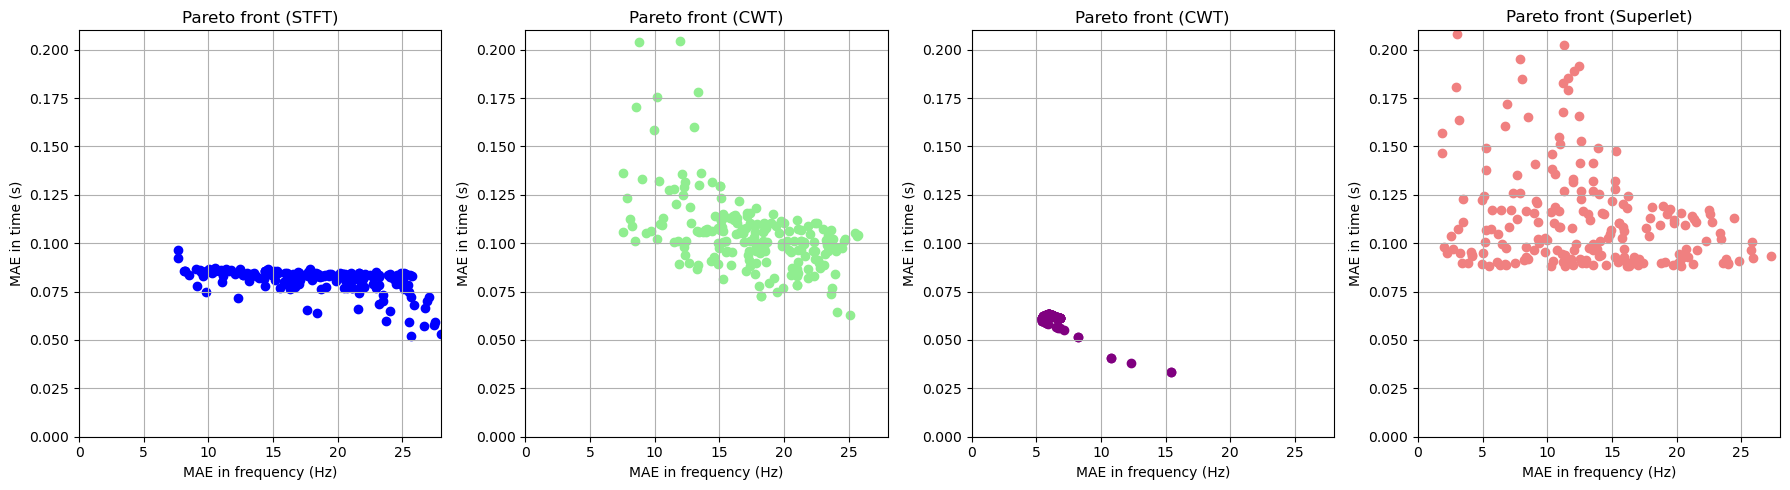

In [105]:
# Calcula los límites a partir de los datos de Superlet
# x_min = min(mae_f_vals_random_superlet)
# x_max = max(mae_f_vals_random_superlet)
# y_min = min(mae_t_vals_random_superlet)
# y_max = max(mae_t_vals_random_superlet)
# 
# # Agrega márgenes
# x_margin = (x_max - x_min) * 0.05
# y_margin = (y_max - y_min) * 0.05
# xlim = (x_min - x_margin, x_max + x_margin)
# ylim = (y_min - y_margin, y_max + y_margin)

# Crear figura con 3 subplots en una fila
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

# Superlet
axs[0].scatter(mae_f_vals_random_sst, mae_t_vals_random_sst, c='blue')
axs[0].set_title("Pareto front (STFT)")
axs[0].set_xlabel("MAE in frequency (Hz)")
axs[0].set_ylabel("MAE in time (s)")
axs[0].set_xlim(0,28)
axs[0].set_ylim(0,0.21)
axs[0].grid(True)

# Wavelet
axs[1].scatter(mae_f_vals_random_cwt, mae_t_vals_random_cwt, c='lightgreen')
axs[1].set_title("Pareto front (CWT)")
axs[1].set_xlabel("MAE in frequency (Hz)")
axs[1].set_ylabel("MAE in time (s)")
axs[1].set_xlim(0,28)
axs[1].set_ylim(0,0.21)
axs[1].grid(True)

axs[2].scatter(mae_f_vals_random_our_cwt, mae_t_vals_random_our_cwt, c='purple')
axs[2].set_title("Pareto front (CWT)")
axs[2].set_xlabel("MAE in frequency (Hz)")
axs[2].set_ylabel("MAE in time (s)")
axs[2].set_xlim(0,28)
axs[2].set_ylim(0,0.21)
axs[2].grid(True)

# STFT
axs[3].scatter(mae_f_vals_random_slt, mae_t_vals_random_slt, c='lightcoral')
axs[3].set_title("Pareto front (Superlet)")
axs[3].set_xlabel("MAE in frequency (Hz)")
axs[3].set_ylabel("MAE in time (s)")
axs[3].set_xlim(0,28)
axs[3].set_ylim(0,0.21)
axs[3].grid(True)

# Ajustar espacio
plt.tight_layout()
plt.show()

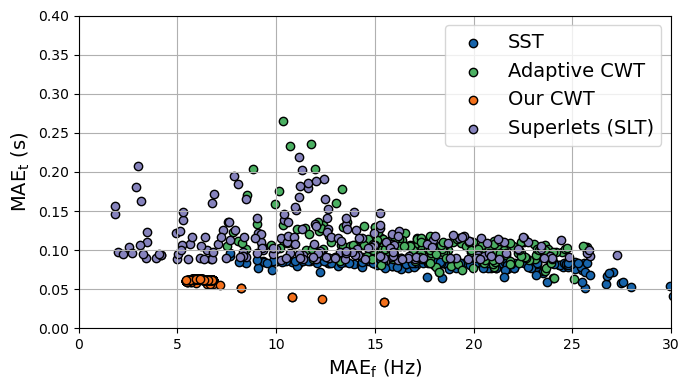

In [108]:
 # Fig tamaño igual al de los subplots (18 x 5)
plt.figure(figsize=(7, 4))

# Misma paleta que definiste
colores_base = {                                 
    "SST": plt.colormaps["Blues"],              
    "Adaptive Wavelet": plt.colormaps["Greens"],          
    "Our Wavelet": plt.colormaps["Oranges"],   
    "Superlet": plt.colormaps["Purples"],    
}  

# Graficar con los mismos colores y estilo
plt.scatter(mae_f_vals_random_sst,
            mae_t_vals_random_sst, 
            color=colores_base["SST"](0.8),
            label='SST',
            edgecolor='black')

plt.scatter(mae_f_vals_random_cwt,
            mae_t_vals_random_cwt,
            color=colores_base["Adaptive Wavelet"](0.6),
            label='Adaptive CWT',
            edgecolor='black')

plt.scatter(mae_f_vals_random_our_cwt,
            mae_t_vals_random_our_cwt,
            color=colores_base["Our Wavelet"](0.6),
            label='Our CWT',
            edgecolor='black')

plt.scatter(mae_f_vals_random_slt,
            mae_t_vals_random_slt,
            color=colores_base["Superlet"](0.6),
            label='Superlets (SLT)',
            edgecolor='black')

# Mismos límites que antes
plt.xlim(0, 28)
plt.ylim(0, 0.4)

# Mismos ejes y estética
plt.xlabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
plt.xticks(np.arange(0, 31, 5))
plt.yticks(np.arange(0, 0.45, 0.05))

plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()

plt.show()
